In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/timeseriesdatadate.csv')

In [3]:
df.head()

,Date,Max,Min
0,01-01-1900,10.34,9.93
1,02-01-1900,9.85,9.55
2,03-01-1900,9.39,8.80
3,04-01-1900,8.95,8.95
4,05-01-1900,8.53,8.30


In [4]:
df.dtypes

,0
Date,object
Max,float64
Min,float64


In [5]:
df.shape

(2479, 3)

In [6]:
df.rename(columns ={'Date':'date','Max':'temp_max','Min':'temp_min'},inplace=True)
df.tail()

,date,temp_max,temp_min
2474,10-10-1906,18.55,17.65
2475,11-10-1906,19.20,18.20
2476,12-10-1906,19.00,18.25
2477,13-10-1906,18.90,18.35
2478,14-10-1906,18.30,17.25


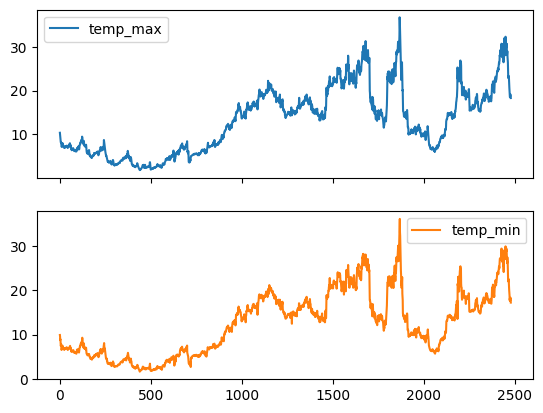

In [7]:
df.plot(subplots=True)
plt.show()

In [8]:
train_temp_max = list(df[0:1800]['temp_max'])
test_temp_max = list(df[1800:]['temp_max'])

In [9]:
train_temp_min = list(df[0:1800]['temp_min'])
test_temp_min = list(df[1800:]['temp_min'])

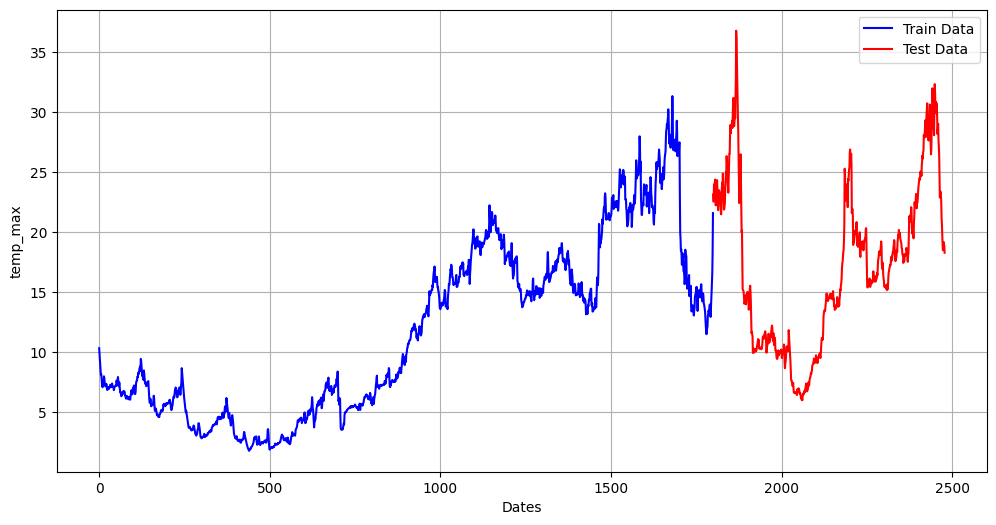

In [10]:
plt.figure(figsize=(12,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('temp_max')
plt.plot(df[0:1800]['temp_max'],'blue',label='Train Data')
plt.plot(df[1800:]['temp_max'],'red',label='Test Data')
plt.legend()

In [11]:
model_prediction_max = []
n_test_obser_tmax = len(test_temp_max)

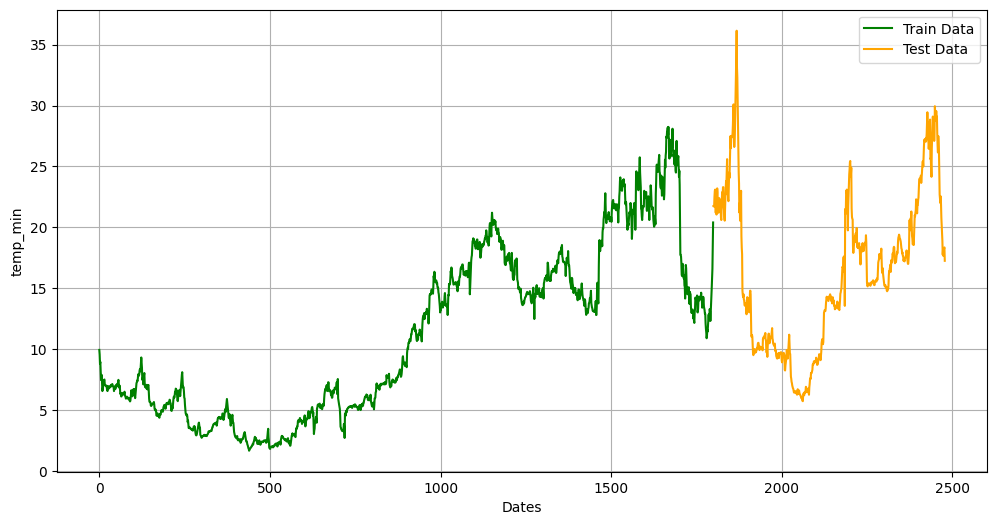

In [12]:
plt.figure(figsize=(12,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('temp_min')
plt.plot(df[0:1800]['temp_min'],'green',label='Train Data')
plt.plot(df[1800:]['temp_min'],'orange',label='Test Data')
plt.legend()

In [13]:
model_prediction_min = []
n_test_obser_tmin = len(test_temp_min)

In [14]:
for i in range(n_test_obser_tmax):
  modelmax = ARIMA(train_temp_max,order =(4,1,0))
  model_max_fit =modelmax.fit()
  output_max = model_max_fit.forecast()
  yhat_max = output_max[0]
  model_prediction_max.append(yhat_max)
  actual_test_value_max = test_temp_max[i]
  train_temp_max.append(actual_test_value_max)

In [17]:
print(model_max_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2478
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -1884.775
Date:                Thu, 14 May 2026   AIC                           3779.549
Time:                        11:09:13   BIC                           3808.623
Sample:                             0   HQIC                          3790.110
                               - 2478                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2245      0.010     22.301      0.000       0.205       0.244
ar.L2         -0.0857      0.011     -8.039      0.000      -0.107      -0.065
ar.L3          0.0143      0.012      1.201      0.2

In [15]:
for i in range(n_test_obser_tmin):
  modelmin = ARIMA(train_temp_min,order =(4,1,0))
  model_min_fit =modelmin.fit()
  output_min = model_min_fit.forecast()
  yhat_min = output_min[0]
  model_prediction_min.append(yhat_min)
  actual_test_value_min = test_temp_min[i]
  train_temp_min.append(actual_test_value_min)

In [18]:
print(model_min_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2478
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -1908.038
Date:                Thu, 14 May 2026   AIC                           3826.075
Time:                        11:09:35   BIC                           3855.149
Sample:                             0   HQIC                          3836.635
                               - 2478                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1017      0.010     10.331      0.000       0.082       0.121
ar.L2          0.0056      0.012      0.470      0.638      -0.018       0.029
ar.L3         -0.0040      0.011     -0.372      0.7

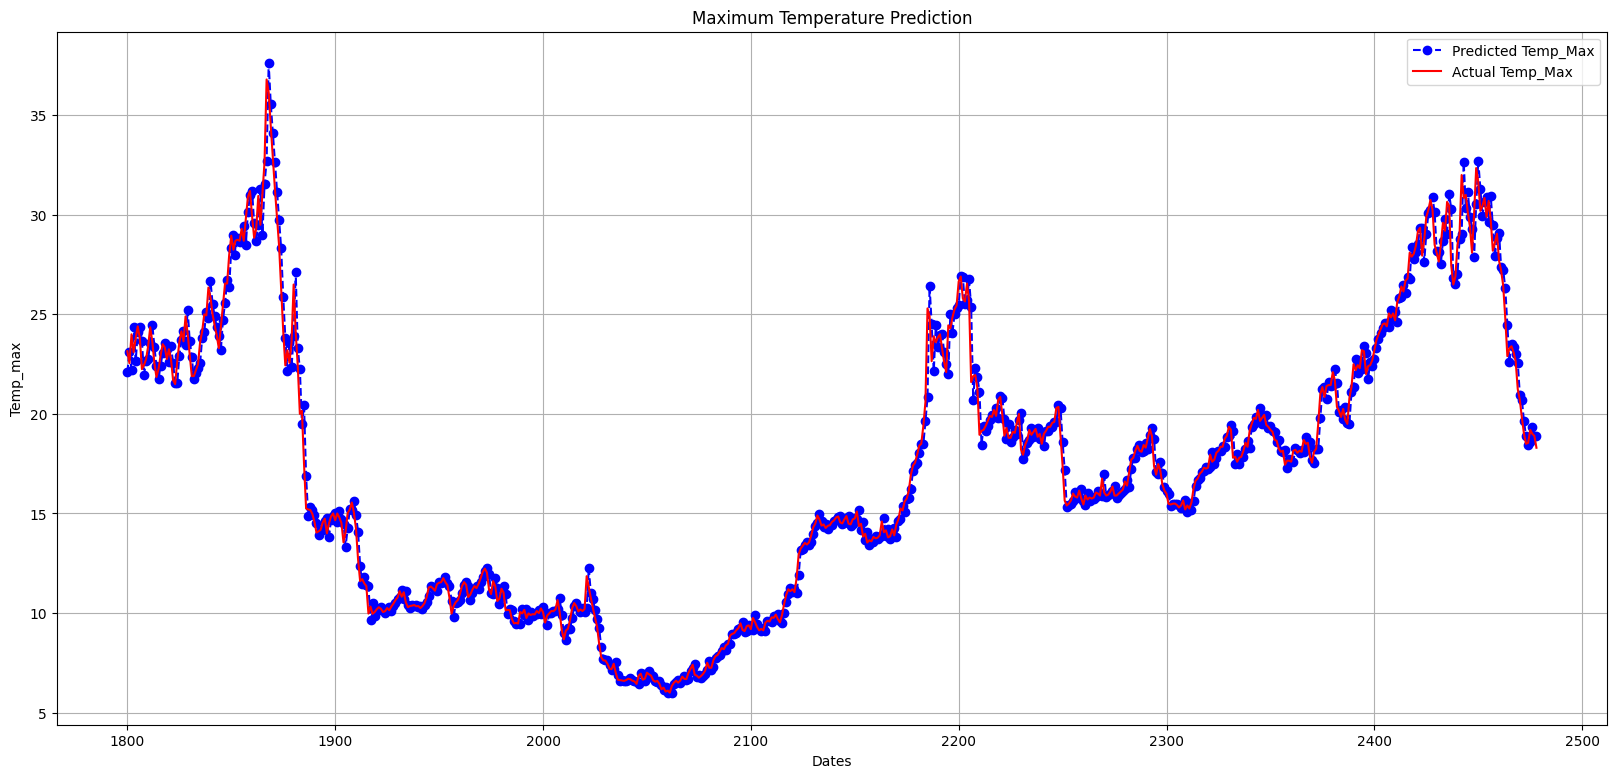

In [19]:
plt.figure(figsize=(20,9))
plt.grid(True)
date_range = df[1800:].index
plt.plot(date_range, model_prediction_max[:],'blue',marker= 'o',linestyle = 'dashed',label='Predicted Temp_Max')
plt.plot(date_range, test_temp_max, 'red', label='Actual Temp_Max')
plt.title('Maximum Temperature Prediction')
plt.xlabel('Dates')
plt.ylabel('Temp_max')
plt.legend()
plt.show()

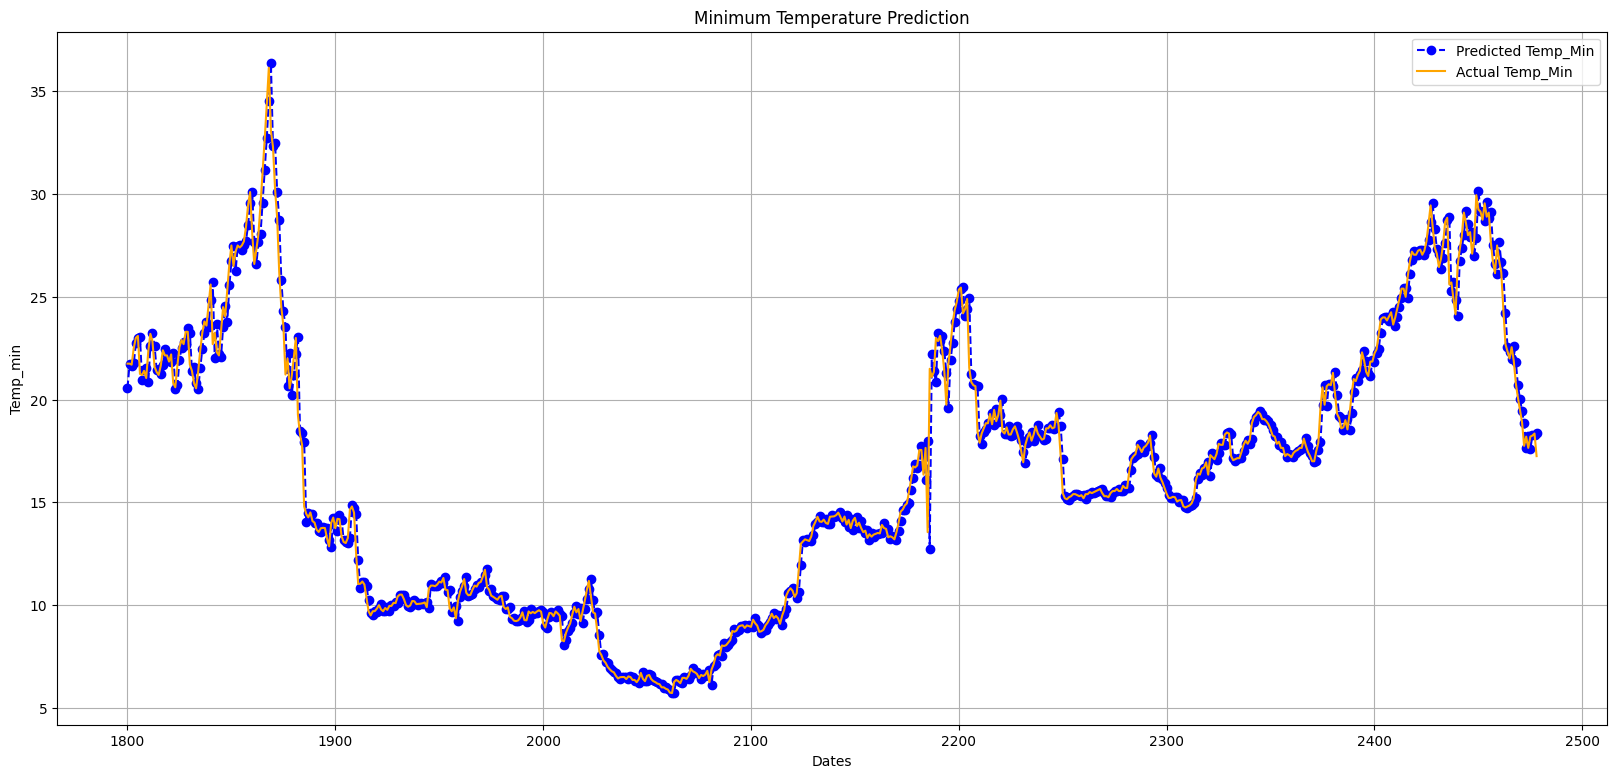

In [20]:
plt.figure(figsize=(20,9))
plt.grid(True)
date_range = df[1800:].index
plt.plot(date_range, model_prediction_min[:],'blue',marker= 'o',linestyle = 'dashed',label='Predicted Temp_Min')
plt.plot(date_range, test_temp_min, 'orange', label='Actual Temp_Min')
plt.title('Minimum Temperature Prediction')
plt.xlabel('Dates')
plt.ylabel('Temp_min')
plt.legend()
plt.show()

In [21]:
mape = np.mean(np.abs(np.array(model_prediction_max[:]) - np.array(test_temp_max))/np.abs(test_temp_max))*100
print('MAPE :'+str(mape))

MAPE :2.61786255524944


In [22]:
mape = np.mean(np.abs(np.array(model_prediction_min[:]) - np.array(test_temp_min))/np.abs(test_temp_min))*100
print('MAPE :'+str(mape))

MAPE :2.5154575811384934
